# Analisis de Agrupamiento de Diabetes

## 1. Introduccion / Hipotesis

Este analisis utiliza el dataset de 130 hospitales de Estados Unidos (1999-2008) con registros de pacientes diabeticos. El objetivo es descubrir patrones ocultos y grupos de pacientes similares mediante tecnicas de aprendizaje no supervisado, sin utilizar las etiquetas de readmision como variables de agrupamiento.

**Importancia clinica:** Identificar subgrupos de pacientes con caracteristicas similares permite explorar la posibilidad de tratamientos personalizados y una mejor asignacion de recursos hospitalarios.

### Hipotesis

**H1:** Existen subgrupos distintivos de pacientes diabeticos con caracteristicas clinicas similares que pueden ser identificados mediante algoritmos de agrupamiento no supervisado.

**H2:** Los patrones de medicacion y resultados de laboratorio revelan clusters con diferentes niveles de riesgo de readmision hospitalaria.

**H3:** Las tecnicas de reduccion dimensional (PCA y t-SNE) mostraran una separacion natural entre los tipos de pacientes, confirmando la existencia de estructura latente en los datos.

## 2. Carga y exploracion de datos

Cargamos el archivo CSV y realizamos una exploracion inicial para comprender la estructura y calidad de los datos.

## 3. Limpieza de datos

En esta fase preparamos los datos para el analisis no supervisado. Documentamos cada paso para garantizar la trazabilidad y reproducibilidad del pipeline.

### Carga de datos y tratamiento de valores faltantes

Cargamos el archivo CSV y reemplazamos los caracteres `"?"` por `NaN`, ya que el dataset original utiliza este simbolo para indicar datos ausentes:

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos el directorio para guardar los graficos
os.makedirs("plots", exist_ok=True)

# Cargamos el dataset
df = pd.read_csv("data/diabetic_data.csv")
print(f"Dimensiones iniciales: {df.shape}")

# Reemplazamos "?" por NaN para que pandas lo reconozca como valor faltante
df.replace("?", np.nan, inplace=True)
print(f"\nTop 5 columnas con mas valores nulos:\n{df.isnull().sum().sort_values(ascending=False).head()}")

Dimensiones iniciales: (101766, 50)

Top 5 columnas con mas valores nulos:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
dtype: int64


In [2]:
# Exploramos la estructura basica del dataset
print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes.value_counts()}")
print(f"\nPrimeras filas:\n{df.head()}")
print(f"\nEstadisticas descriptivas:\n{df.describe().round(2)}")
print(f"\nDistribucion de readmitted:\n{df['readmitted'].value_counts()}")
print(f"\nValores unicos por columna categorica:")
for col in df.select_dtypes(include=["object"]).columns:
    print(f"  {col}: {df[col].nunique()} valores unicos")

Dimensiones: (101766, 50)

Tipos de datos:
object    37
int64     13
Name: count, dtype: int64

Primeras filas:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  .

### Eliminacion de columnas con alto porcentaje de valores faltantes

Las columnas con mas del 40% de datos ausentes no aportan informacion confiable, por lo que las eliminamos para evitar sesgos en la imputacion:

In [3]:
# Calculamos el porcentaje de valores nulos por columna
missing_pct = df.isnull().mean() * 100

# Eliminamos columnas con >40% de nulos, incluyendo las especificadas en AGENTS.md
cols_to_drop_explicit = ["weight", "payer_code", "medical_specialty"]
cols_to_drop_threshold = missing_pct[missing_pct > 40].index.tolist()
cols_to_drop = sorted(set(cols_to_drop_explicit + cols_to_drop_threshold))
print(f"Columnas eliminadas: {cols_to_drop}")

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print(f"Dimensiones tras eliminar columnas: {df.shape}")

Columnas eliminadas: ['A1Cresult', 'max_glu_serum', 'medical_specialty', 'payer_code', 'weight']
Dimensiones tras eliminar columnas: (101766, 45)


### Eliminacion de columnas identificadoras

Los identificadores de encuentro y paciente no contienen patrones clinicos, por lo que los eliminamos antes del modelado para evitar que el algoritmo los interprete como variables numericas:

In [4]:
# Eliminamos las columnas de identificadores
df.drop(columns=["encounter_id", "patient_nbr"], inplace=True)
print(f"Dimensiones tras eliminar IDs: {df.shape}")

Dimensiones tras eliminar IDs: (101766, 43)


In [5]:
# Cargamos el archivo de mapeo de IDs para enriquecer las columnas numericas
ids_map = pd.read_csv("data/IDS_mapping.csv", header=None)

# Separamos las tres secciones por filas vacias
blank_rows = ids_map[ids_map.iloc[:, 0].isna()].index.tolist()
sections = []
start = 0
for br in blank_rows:
    sections.append(ids_map.iloc[start:br].dropna())
    start = br + 1
sections.append(ids_map.iloc[start:].dropna())

# Creamos diccionarios de mapeo (saltando la fila de encabezado de cada seccion)
mapping_dicts = {}
col_names = ["admission_type", "discharge_disposition", "admission_source"]
for section, name in zip(sections, col_names):
    data_rows = section.iloc[1:]  # descartamos la fila de encabezado
    data_rows.columns = ["id", "description"]
    mapping_dicts[name] = dict(zip(data_rows["id"].astype(int), data_rows["description"]))

# Aplicamos los mapeos a las columnas correspondientes
for col_name, mapping in mapping_dicts.items():
    id_col = col_name + "_id"
    if id_col in df.columns:
        df[col_name] = df[id_col].map(mapping).fillna("Desconocido")
        print(f"Mapeo aplicado a {id_col}: {len(mapping)} categorias")

# Eliminamos las columnas _id originales que ahora estan representadas por las columnas mapeadas
id_cols_to_drop = [col_name + "_id" for col_name in mapping_dicts if col_name + "_id" in df.columns]
df.drop(columns=id_cols_to_drop, inplace=True)
print(f"Columnas _id eliminadas: {id_cols_to_drop}")
print(f"Dimensiones finales tras mapeo: {df.shape}")

Mapeo aplicado a admission_type_id: 7 categorias
Mapeo aplicado a discharge_disposition_id: 29 categorias
Mapeo aplicado a admission_source_id: 24 categorias
Columnas _id eliminadas: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
Dimensiones finales tras mapeo: (101766, 43)


### Eliminacion de registros duplicados

Eliminamos las filas exactamente iguales para evitar sobreponderar ciertos patrones durante el clustering:

In [6]:
duplicates = df.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicates}")
df.drop_duplicates(inplace=True)
print(f"Dimensiones tras eliminar duplicados: {df.shape}")

Registros duplicados encontrados: 0
Dimensiones tras eliminar duplicados: (101766, 43)


### Imputacion de valores faltantes

Rellenamos los valores restantes usando la mediana para variables numericas (robusta a outliers) y la moda para variables categoricas:

In [7]:
# Separamos las columnas por tipo de dato
numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

# Aplicamos imputacion numerica con mediana
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Aplicamos imputacion categorica con moda
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Valores nulos restantes: {df.isnull().sum().sum()}")

Valores nulos restantes: 0


### Codificacion de variables categoricas

Aplicamos un encoding diferenciado segun el tipo de variable:
- **Nominales** (sin orden): One-Hot Encoding para `race`, `gender`, `admission_type`, `discharge_disposition`, `admission_source`
- **Ordinales** (con orden natural): mapeo numerico para `age` ([0-10)=0, [10-20)=1, ...) y medicamentos (No=0, Steady=1, Down=2, Up=3)
- **Diagnosticos** (`diag_1`, `diag_2`, `diag_3`): tienen mas de 700 categorias cada una, lo que haria inviable el One-Hot. Los eliminamos para evitar ruido y dimensionalidad excesiva.

`LabelEncoder` impone un orden arbitrario en variables nominales que distorsiona las distancias euclidianas. One-Hot Encoding evita este problema.

In [8]:
# --- 1. Eliminamos diagnosticos (demasiadas categorias para One-Hot) ---
diag_cols = ["diag_1", "diag_2", "diag_3"]
df.drop(columns=[c for c in diag_cols if c in df.columns], inplace=True)
print(f"Columnas de diagnostico eliminadas: {diag_cols}")

# --- 2. Encoding ordinal para medicamentos (No=0, Steady=1, Down=2, Up=3) ---
med_mapping = {"No": 0, "Steady": 1, "Down": 2, "Up": 3}
medication_cols = ["metformin", "repaglinide", "nateglinide", "chlorpropamide",
                   "glimepiride", "acetohexamide", "glipizide", "glyburide",
                   "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
                   "miglitol", "troglitazone", "tolazamide", "examide",
                   "citoglipton", "insulin", "glyburide-metformin",
                   "glipizide-metformin", "glimepiride-pioglitazone",
                   "metformin-rosiglitazone", "metformin-pioglitazone"]
for col in medication_cols:
    if col in df.columns:
        df[col] = df[col].map(med_mapping).fillna(0).astype(int)

# --- 3. Encoding ordinal para age (orden natural) ---
age_order = sorted([v for v in df["age"].dropna().unique()],
                   key=lambda x: int(x.strip("[]()").split("-")[0]))
age_mapping = {v: i for i, v in enumerate(age_order)}
df["age"] = df["age"].map(age_mapping).fillna(0).astype(int)

# --- 4. Encoding binario para change y diabetesMed ---
binary_mapping = {"No": 0, "No": 0, "Yes": 1, "Ch": 1}
for col in ["change", "diabetesMed"]:
    if col in df.columns:
        df[col] = df[col].map(binary_mapping).fillna(0).astype(int)

# --- 5. One-Hot Encoding para nominales ---
nominal_cols = ["race", "gender", "admission_type", "discharge_disposition", "admission_source"]
nominal_present = [c for c in nominal_cols if c in df.columns]
df = pd.get_dummies(df, columns=nominal_present, dtype=int)

print(f"One-Hot aplicado a: {nominal_present}")
print(f"Ordinal aplicado a: age, {medication_cols[:3]}... ({len(medication_cols)} cols)")
print(f"Dimensiones tras encoding: {df.shape}")
print(df.head())

Columnas de diagnostico eliminadas: ['diag_1', 'diag_2', 'diag_3']
One-Hot aplicado a: ['race', 'gender', 'admission_type', 'discharge_disposition', 'admission_source']
Ordinal aplicado a: age, ['metformin', 'repaglinide', 'nateglinide']... (23 cols)
Dimensiones tras encoding: (101766, 94)
   age  time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0    0                 1                  41               0                1   
1    1                 3                  59               0               18   
2    2                 2                  11               5               13   
3    3                 2                  44               1               16   
4    4                 1                  51               0                8   

   number_outpatient  number_emergency  number_inpatient  number_diagnoses  \
0                  0                 0                 0                 1   
1                  0                 0                 0          

### Deteccion y manejo de valores atipicos (Outliers)

Utilizamos el metodo del rango intercuartilico (IQR) para identificar outliers en variables numericas. En lugar de eliminarlos, los limitamos (winsorize) a los limites inferior y superior para preservar el tamano de la muestra:

In [9]:
# Aplicamos el metodo IQR solo a variables continuas (no binarias ni ordinales de baja cardinalidad)
# Las columnas one-hot (0/1), ordinales de medicamentos (0-3) y age (0-9) no deben winsorizarse.
continuous_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                   "num_medications", "number_outpatient", "number_emergency",
                   "number_inpatient", "number_diagnoses"]
continuous_cols = [c for c in continuous_cols if c in df.columns]

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print(f"Outliers limitados en {len(continuous_cols)} columnas continuas: {continuous_cols}")

Outliers limitados en 8 columnas continuas: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


### Normalizacion de datos

Aplicamos `StandardScaler` para estandarizar todas las caracteristicas a media 0 y desviacion estandar 1. Esto es crucial para algoritmos basados en distancias como K-Means y DBSCAN:

In [10]:
from sklearn.preprocessing import LabelEncoder

# Separamos las columnas de referencia (no participan en clustering)
reference_cols = ["readmitted"]
model_cols = [c for c in df.columns if c not in reference_cols]

# Escalamos solo las columnas de modelado
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[model_cols]), columns=model_cols)

# Codificamos readmitted con LabelEncoder solo para visualizacion (color en plots)
le_readmitted = LabelEncoder()
df_scaled["readmitted"] = le_readmitted.fit_transform(df["readmitted"].astype(str))
print(f"Mapeo readmitted: {dict(zip(le_readmitted.classes_, le_readmitted.transform(le_readmitted.classes_)))}")

print("Datos normalizados con StandardScaler (columnas de modelado).")
print(f"Columnas de modelado: {len(model_cols)}")
print(df_scaled.describe().round(4))

Mapeo readmitted: {'<30': np.int64(0), '>30': np.int64(1), 'NO': np.int64(2)}
Datos normalizados con StandardScaler (columnas de modelado).
Columnas de modelado: 93
               age  time_in_hospital  num_lab_procedures  num_procedures  \
count  101766.0000       101766.0000         101766.0000     101766.0000   
mean        0.0000           -0.0000              0.0000         -0.0000   
std         1.0000            1.0000              1.0000          1.0000   
min        -3.8246           -1.1630             -2.1420         -0.8162   
25%        -0.6880           -0.8172             -0.6152         -0.8162   
50%        -0.0607           -0.1257              0.0465         -0.1840   
75%         0.5667            0.5658              0.7081          0.4482   
max         1.8213            2.6404              2.6929          2.3447   

       num_medications  number_outpatient  number_emergency  number_inpatient  \
count      101766.0000           101766.0          101766.0       101

In [11]:
from sklearn.feature_selection import VarianceThreshold

# Identificamos y eliminamos caracteristicas con varianza casi nula
var_threshold = VarianceThreshold(threshold=0.01)
var_threshold.fit(df_scaled[model_cols])

mask = var_threshold.get_support()
kept_features = df_scaled[model_cols].columns[mask]
dropped_features = df_scaled[model_cols].columns[~mask]

print(f"Caracteristicas eliminadas por baja varianza: {list(dropped_features)}")
print(f"Caracteristicas retenidas: {len(kept_features)}")

# Reconstruimos df_scaled solo con las caracteristicas utiles
df_scaled = df_scaled[kept_features.tolist() + reference_cols]
print(f"Dimensiones finales para clustering: {df_scaled.shape}")

Caracteristicas eliminadas por baja varianza: ['number_outpatient', 'number_emergency', 'examide', 'citoglipton']
Caracteristicas retenidas: 89
Dimensiones finales para clustering: (101766, 90)


In [12]:
# Separamos las columnas de modelado (sin readmitted) para usar en PCA, t-SNE y clustering
df_clustering = df_scaled.drop(columns=["readmitted"])
print(f"Columnas de modelado para clustering: {len(df_clustering.columns)}")

Columnas de modelado para clustering: 89


### Exportacion del dataset limpio

Guardamos el dataframe procesado para su uso en las siguientes etapas del pipeline (EDA, reduccion dimensional y clustering):

In [13]:
# Guardamos el dataset limpio
df_scaled.to_csv("data/diabetes_cleaned.csv", index=False)
print("Dataset limpio guardado como data/diabetes_cleaned.csv")

Dataset limpio guardado como data/diabetes_cleaned.csv


## 4. EDA: correlaciones, distribuciones, pairplot, umbral de varianza

En esta fase exploramos las relaciones, distribuciones y patrones en los datos limpios para guiar las decisiones de modelado.

### Distribuciones antes/despues de limpieza

Comparamos las distribuciones de variables numericas clave antes y despues del proceso de limpieza para verificar el impacto del tratamiento de outliers y normalizacion:

*(Nota: las distribuciones originales se capturaron durante la fase de limpieza. Consultamos los graficos en plots/ para la comparacion visual.)*

### Heatmap de correlaciones

Visualizamos la matriz de correlacion entre variables numericas para detectar multicolinealidad y relaciones fuertes:

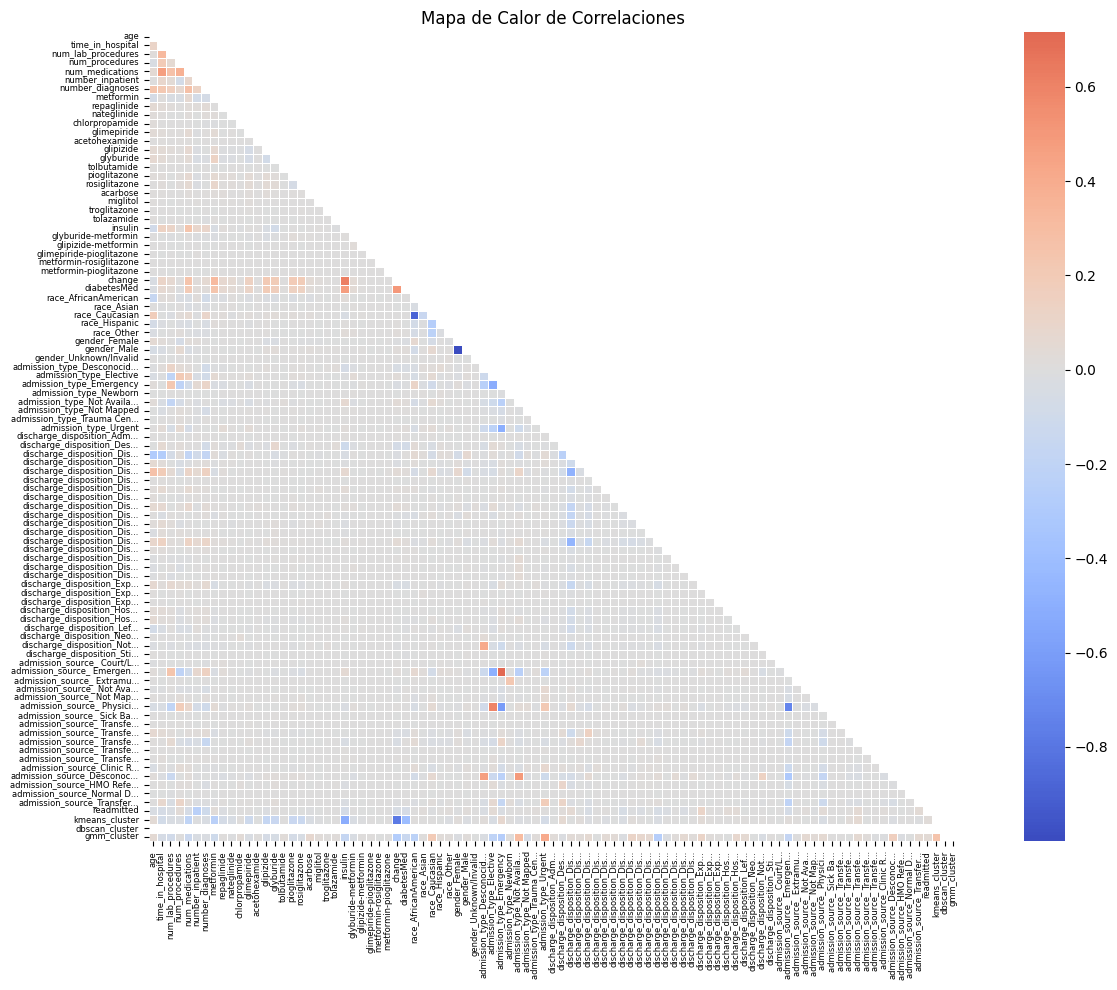

In [36]:
# Calculamos la matriz de correlacion
corr_matrix = df_scaled.corr()

# Truncamos etiquetas largas para que el heatmap sea legible
short_names = [c[:25] + "..." if len(c) > 25 else c for c in corr_matrix.columns]
corr_matrix.index = short_names
corr_matrix.columns = short_names

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, square=True, linewidths=0.5, annot=False,
            xticklabels=True, yticklabels=True)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.title("Mapa de Calor de Correlaciones")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=300)
plt.show()

### Distribucion de la variable readmitted (referencia)

Aunque no usamos esta variable como etiqueta para clustering, la visualizamos para entender la proporcion de readmisiones como referencia clinica:

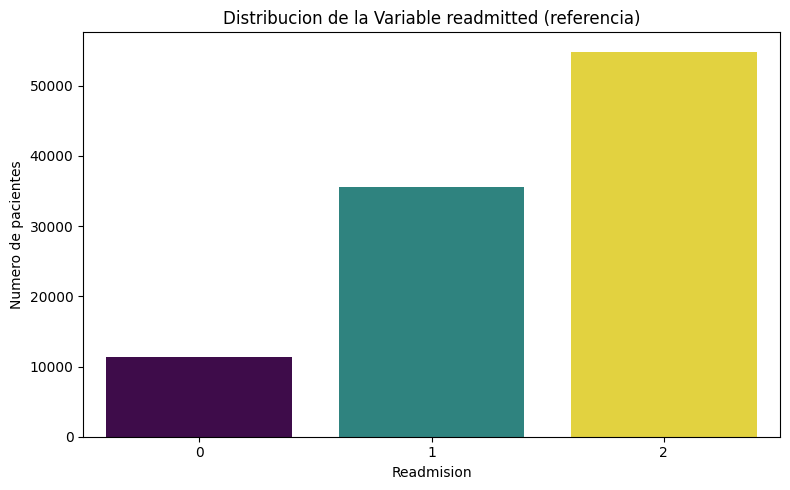

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x="readmitted", data=df_scaled, hue="readmitted", palette="viridis", legend=False)
plt.title("Distribucion de la Variable readmitted (referencia)")
plt.xlabel("Readmision")
plt.ylabel("Numero de pacientes")
plt.tight_layout()
plt.savefig("plots/readmitted_distribution.png", dpi=300)
plt.show()

### Distribuciones de variables numericas seleccionadas

Observamos las distribuciones de las variables numericas clave tras la limpieza y normalizacion:

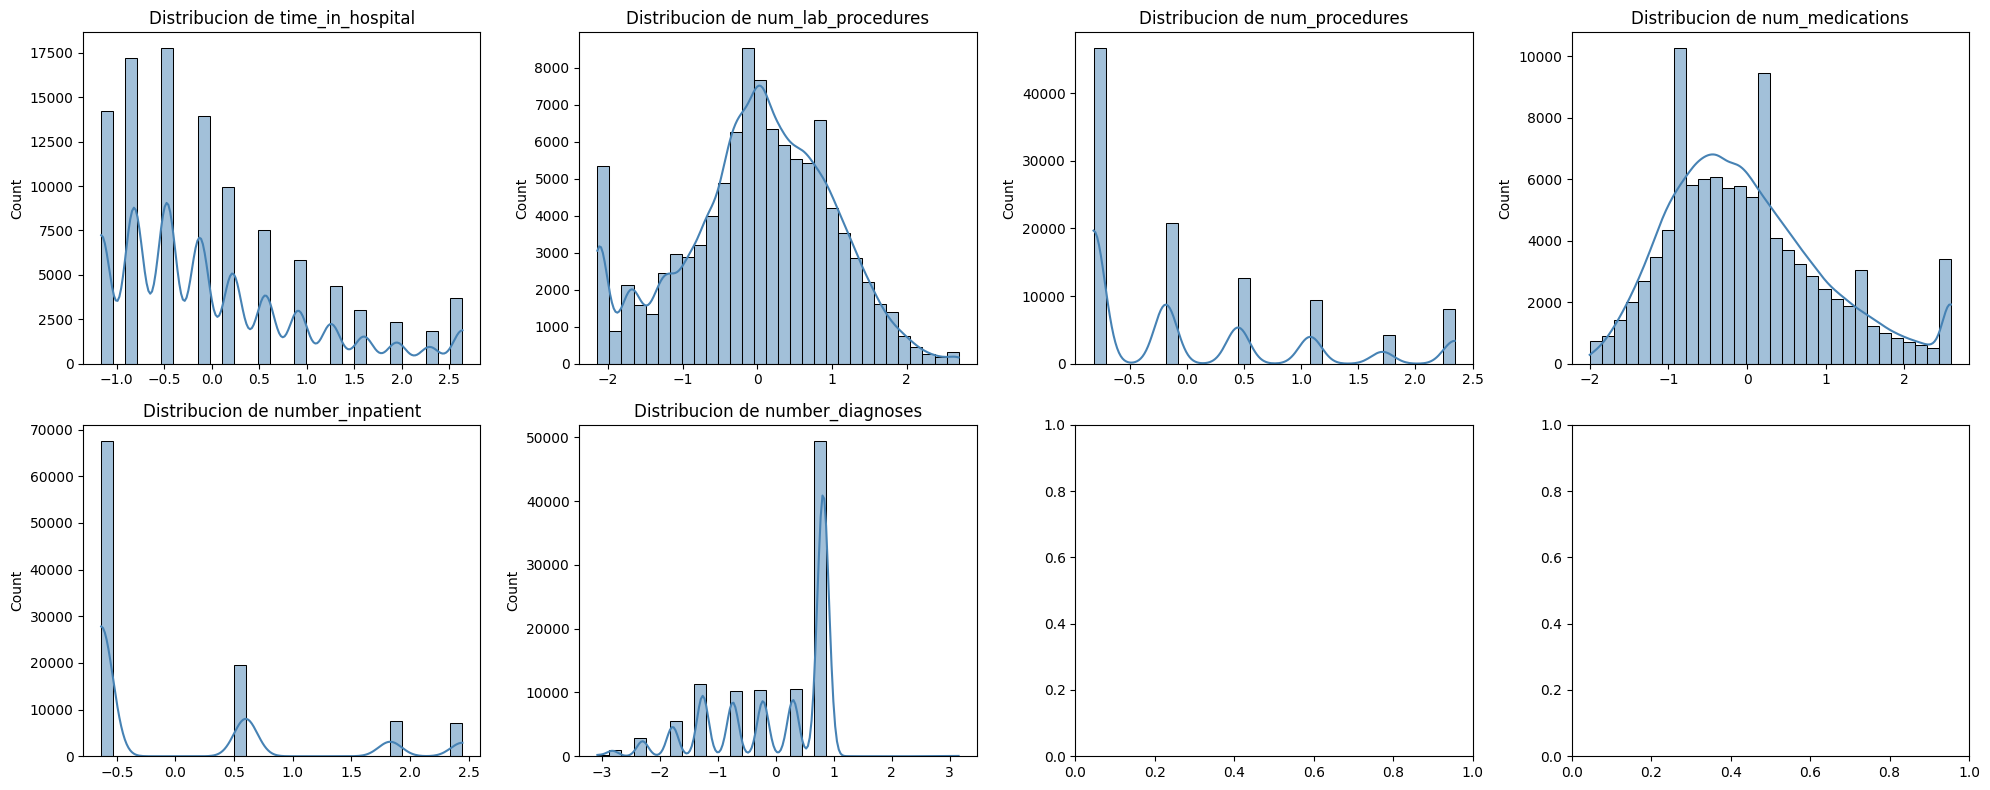

In [16]:
numeric_features = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                    "num_medications", "number_outpatient", "number_emergency",
                    "number_inpatient", "number_diagnoses"]
# Filtramos solo las columnas que existan en df_scaled (VarianceThreshold puede haber eliminado algunas)
numeric_features = [c for c in numeric_features if c in df_scaled.columns]


fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df_scaled[col], kde=True, ax=axes[i], bins=30, color="steelblue")
    axes[i].set_title(f"Distribucion de {col}")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.savefig("plots/numeric_distributions.png", dpi=300)
plt.show()

### Pairplot de variables principales

Visualizamos las relaciones entre un subconjunto de variables clave, coloreadas por readmitted para referencia visual:

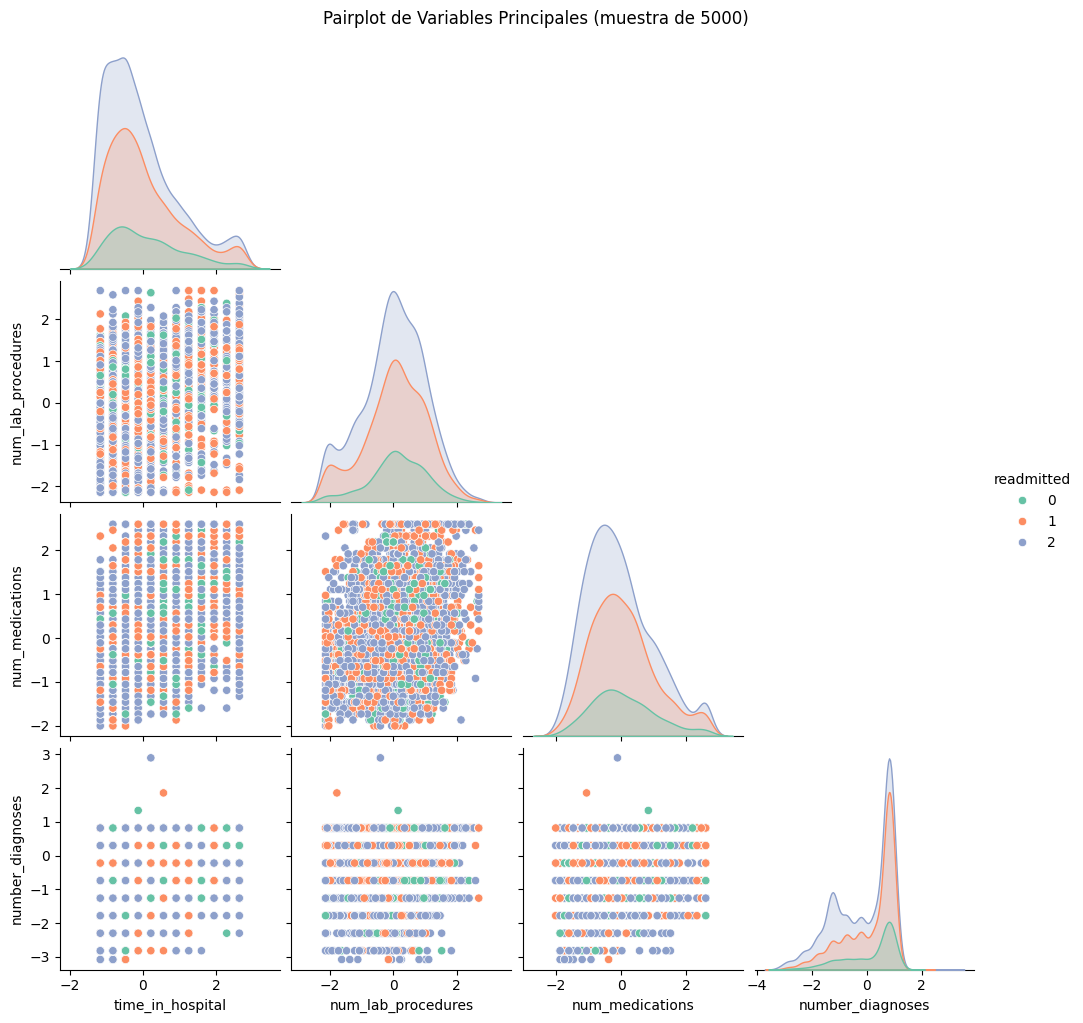

In [17]:
pairplot_cols = ["time_in_hospital", "num_lab_procedures", "num_medications", "number_diagnoses", "readmitted"]

# Usamos una muestra para que el pairplot sea manejable
sample = df_scaled[pairplot_cols].sample(n=5000, random_state=42)
g = sns.pairplot(sample, hue="readmitted", palette="Set2", corner=True)
g.fig.suptitle("Pairplot de Variables Principales (muestra de 5000)", y=1.02)
g.savefig("plots/pairplot_main.png", dpi=300)
plt.show()

### Importancia de variables por varianza

Calculamos la varianza de cada caracteristica para identificar cuales aportan mayor variabilidad al dataset. Las variables con varianza cercana a cero podrian eliminarse en un umbral de varianza:

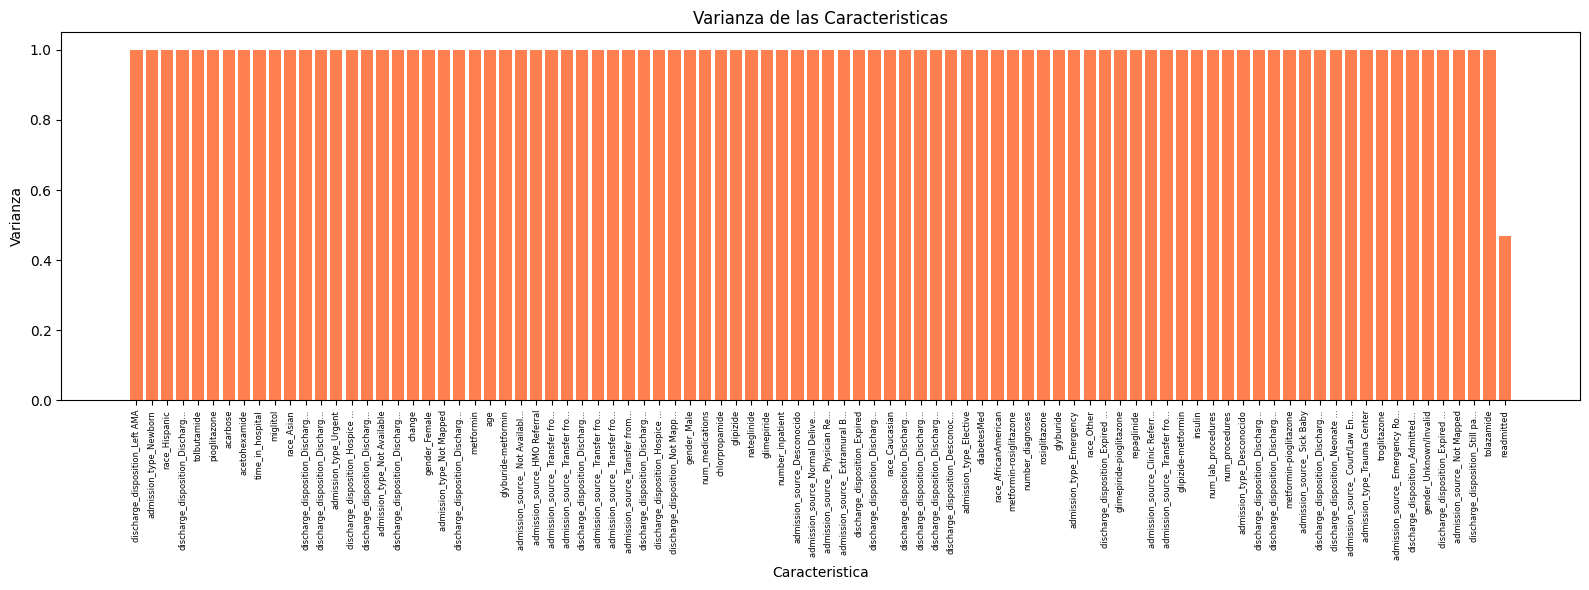

discharge_disposition_Left AMA                                                                             1.00001
admission_type_Newborn                                                                                     1.00001
race_Hispanic                                                                                              1.00001
discharge_disposition_Discharged/transferred to another rehab fac including rehab units of a hospital .    1.00001
tolbutamide                                                                                                1.00001
                                                                                                            ...   
discharge_disposition_Expired at home. Medicaid only, hospice.                                             1.00001
admission_source_ Not Mapped                                                                               1.00001
discharge_disposition_Still patient or expected to return for outpatient service

In [18]:
variances = df_scaled.var().sort_values(ascending=False)

# Truncamos etiquetas largas para que no ocupen demasiado espacio en el grafico
short_labels = [c[:30] + "..." if len(c) > 30 else c for c in variances.index]

plt.figure(figsize=(16, 6))
plt.bar(range(len(variances)), variances.values, color="coral")
plt.title("Varianza de las Caracteristicas")
plt.xlabel("Caracteristica")
plt.ylabel("Varianza")
plt.xticks(range(len(variances)), short_labels, rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("plots/variance_features.png", dpi=300)
plt.show()

print(variances)

## 5. Reduccion dimensional: PCA (2D + 3D) y t-SNE

Aplicamos tecnicas de reduccion dimensional para visualizar la estructura latente de los datos en 2D y 3D.

### Varianza explicada acumulada

Antes de reducir a 2 o 3 componentes, analizamos cuantos componentes necesitamos para retener la mayor parte de la informacion. Esto nos permite dimensionar correctamente la reduccion y entender la complejidad intrinseca de los datos:

Componentes para 80% de varianza: 60
Componentes para 90% de varianza: 70


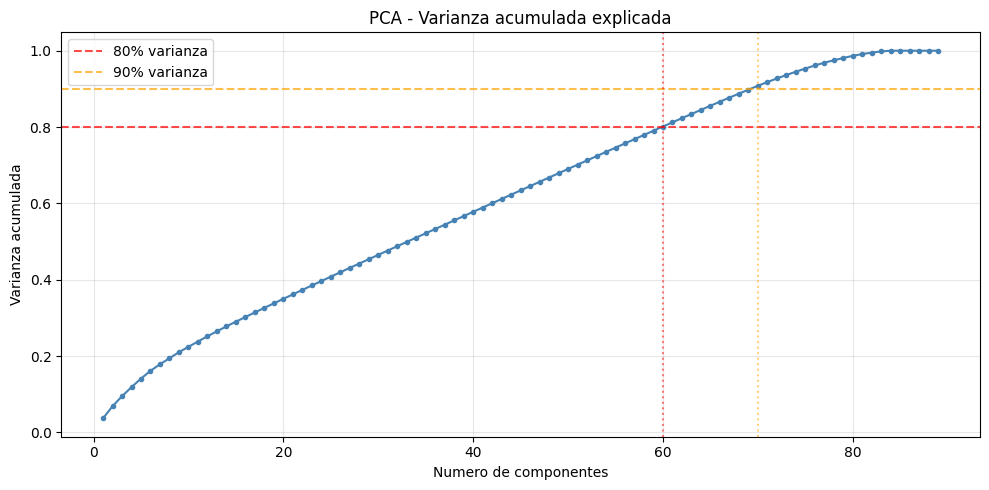

In [19]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42).fit(df_clustering)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = int(np.argmax(cumvar >= 0.80) + 1)
n_components_90 = int(np.argmax(cumvar >= 0.90) + 1)

print(f"Componentes para 80% de varianza: {n_components_80}")
print(f"Componentes para 90% de varianza: {n_components_90}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker=".", color="steelblue")
plt.axhline(0.80, color="red", linestyle="--", alpha=0.7, label="80% varianza")
plt.axhline(0.90, color="orange", linestyle="--", alpha=0.7, label="90% varianza")
plt.axvline(n_components_80, color="red", linestyle=":", alpha=0.5)
plt.axvline(n_components_90, color="orange", linestyle=":", alpha=0.5)
plt.title("PCA - Varianza acumulada explicada")
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pca_cumulative_variance.png", dpi=300)
plt.show()

### PCA 2D y 3D

Reducimos el dataset a 2 y 3 componentes principales para visualizar la distribucion de pacientes:

Varianza explicada por componente: [3.67419457 3.17689301]


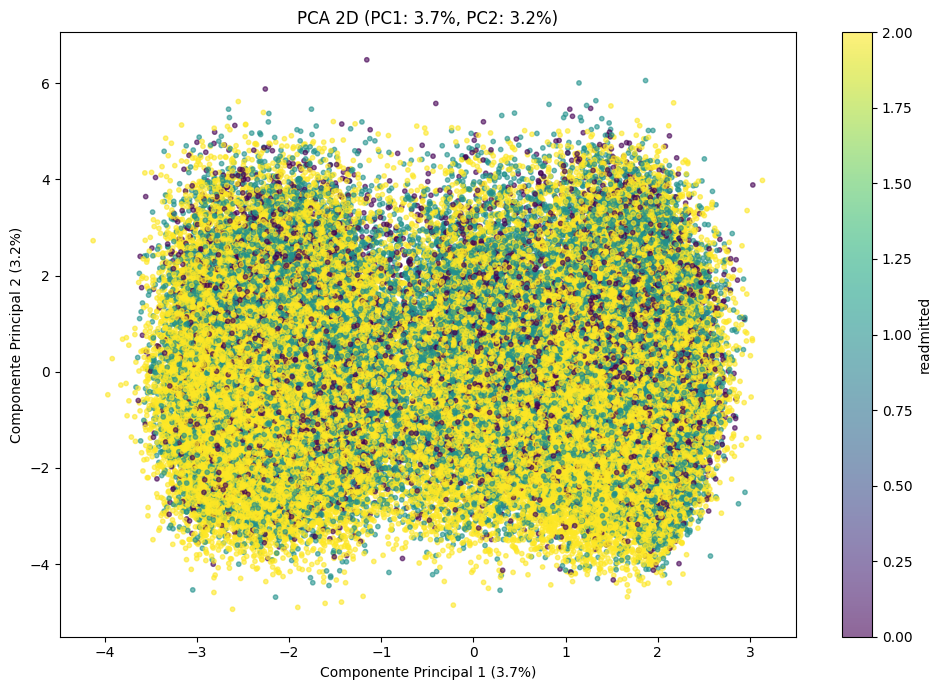

In [20]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
pca_2d_result = pca_2d.fit_transform(df_clustering)

explained_var = pca_2d.explained_variance_ratio_ * 100
print(f"Varianza explicada por componente: {explained_var}")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_2d_result[:, 0], pca_2d_result[:, 1],
                      c=df_scaled["readmitted"], cmap="viridis", alpha=0.6, s=10)
plt.title(f"PCA 2D (PC1: {explained_var[0]:.1f}%, PC2: {explained_var[1]:.1f}%)")
plt.xlabel(f"Componente Principal 1 ({explained_var[0]:.1f}%)")
plt.ylabel(f"Componente Principal 2 ({explained_var[1]:.1f}%)")
plt.colorbar(scatter, label="readmitted")
plt.tight_layout()
plt.savefig("plots/pca_2d.png", dpi=300)
plt.show()

### PCA 3D

Agregamos un tercer componente para capturar mas variabilidad y observar separacion adicional:

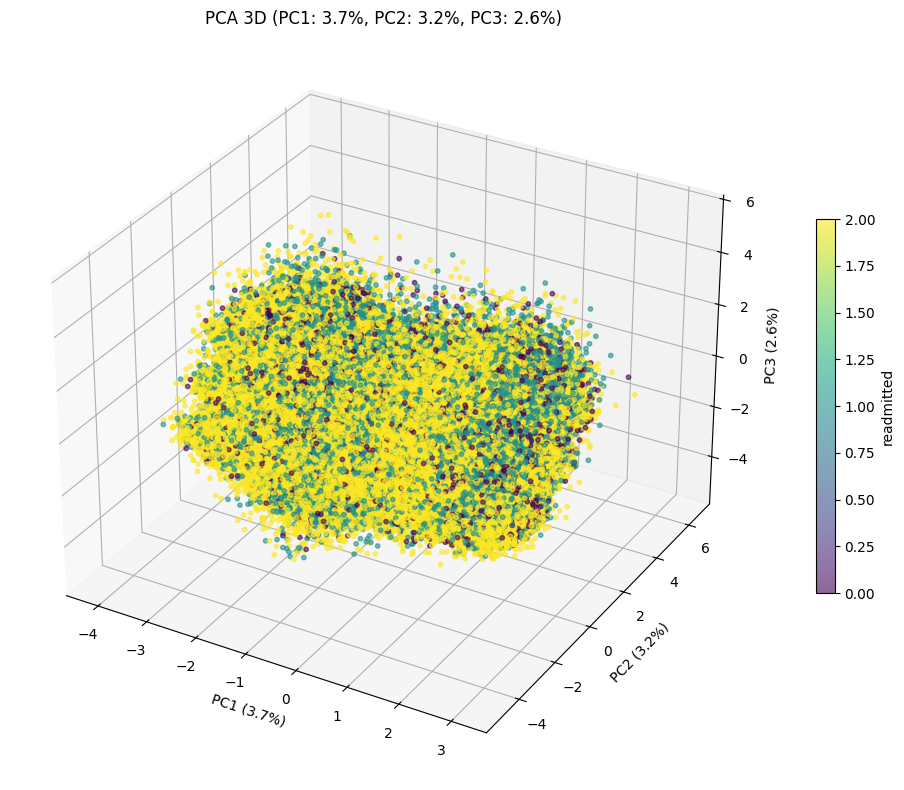

In [21]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
pca_3d_result = pca_3d.fit_transform(df_clustering)

explained_var_3d = pca_3d.explained_variance_ratio_ * 100

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(pca_3d_result[:, 0], pca_3d_result[:, 1], pca_3d_result[:, 2],
                     c=df_scaled["readmitted"], cmap="viridis", alpha=0.6, s=10)
ax.set_title(f"PCA 3D (PC1: {explained_var_3d[0]:.1f}%, PC2: {explained_var_3d[1]:.1f}%, PC3: {explained_var_3d[2]:.1f}%)")
ax.set_xlabel(f"PC1 ({explained_var_3d[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_var_3d[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({explained_var_3d[2]:.1f}%)")
fig.colorbar(scatter, label="readmitted", shrink=0.5)
plt.tight_layout()
plt.savefig("plots/pca_3d.png", dpi=300)
plt.show()

### t-SNE

t-SNE preserva la estructura local de los datos, revelando clusters que PCA podria no capturar. Usamos una muestra de 10000 registros para reducir el tiempo de computo:

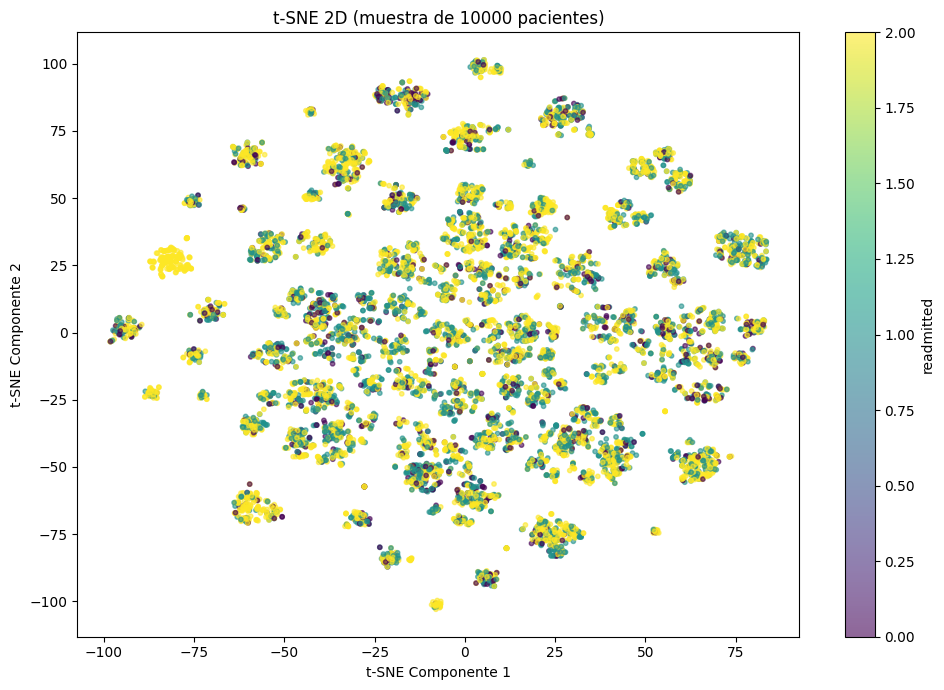

In [22]:
from sklearn.manifold import TSNE

# Usamos una muestra para eficiencia
sample_size = 10000
df_sample = df_clustering.sample(n=sample_size, random_state=42)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result = tsne.fit_transform(df_sample)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1],
                      c=df_scaled.loc[df_sample.index, "readmitted"], cmap="viridis", alpha=0.6, s=10)
plt.title(f"t-SNE 2D (muestra de {sample_size} pacientes)")
plt.xlabel("t-SNE Componente 1")
plt.ylabel("t-SNE Componente 2")
plt.colorbar(scatter, label="readmitted")
plt.tight_layout()
plt.savefig("plots/tsne_2d.png", dpi=300)
plt.show()

## 6. K-Means clustering (elbow, silhouette, profiling)

Aplicamos el algoritmo K-Means para descubrir grupos naturales de pacientes. Evaluamos el numero optimo de clusters mediante el metodo del codo y el silhouette score.

### Metodo del codo (Elbow Method)

Evaluamos la inercia para distintos valores de k (2 a 10) e identificamos el punto de inflexion:

k=2: silhouette=0.0844, cluster mas pequeno=40855 (40.15%)
k=3: silhouette=0.0290, cluster mas pequeno=29063 (28.56%)
k=4: silhouette=0.0955, cluster mas pequeno=855 (0.84%)
k=5: silhouette=0.0370, cluster mas pequeno=9094 (8.94%)
k=6: silhouette=0.0480, cluster mas pequeno=2 (0.00%)
k=7: silhouette=0.0602, cluster mas pequeno=12 (0.01%)
k=8: silhouette=0.0610, cluster mas pequeno=8 (0.01%)
k=9: silhouette=0.0557, cluster mas pequeno=1 (0.00%)
k=10: silhouette=0.0778, cluster mas pequeno=1 (0.00%)


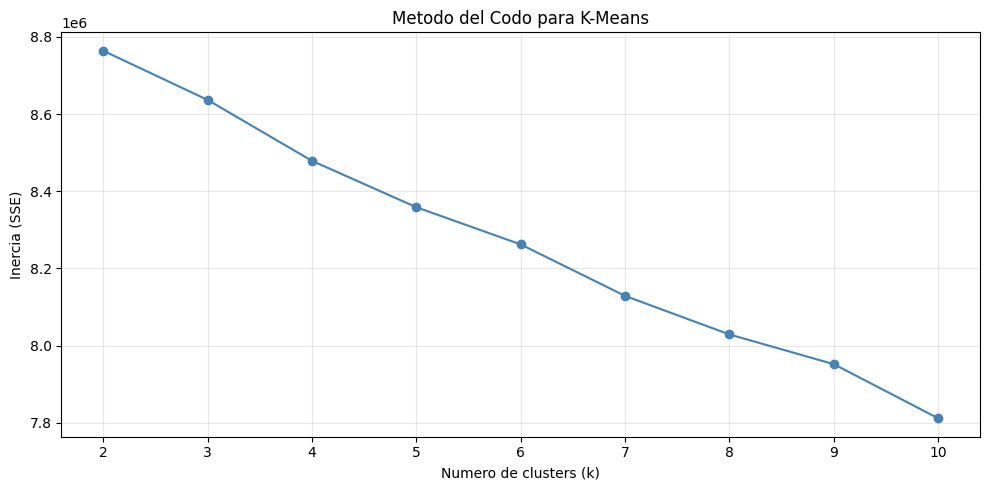

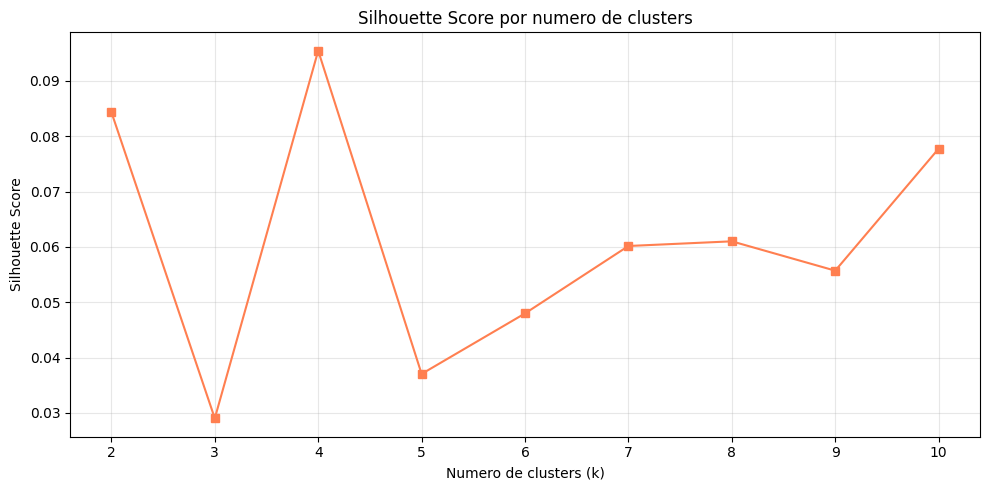

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from collections import Counter

# Usamos solo las columnas de modelado (sin readmitted) para clustering
# df_clustering ya fue definido en la seccion de limpieza (tras VarianceThreshold)

inertias = []
silhouette_scores = []
min_cluster_sizes = []
k_range = range(2, 11)

# Porcentaje minimo del total que debe tener cada cluster para ser valido
MIN_CLUSTER_PCT = 0.01

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(df_clustering)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(df_clustering, kmeans.labels_)
    silhouette_scores.append(sil)
    # Tamano del cluster mas pequeno
    counts = Counter(kmeans.labels_)
    min_size = min(counts.values())
    min_cluster_sizes.append(min_size)
    min_pct = min_size / len(df_clustering) * 100
    print(f"k={k}: silhouette={sil:.4f}, cluster mas pequeno={min_size} ({min_pct:.2f}%)")

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker="o", color="steelblue")
plt.title("Metodo del Codo para K-Means")
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Inercia (SSE)")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/kmeans_elbow.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker="s", color="coral")
plt.title("Silhouette Score por numero de clusters")
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/kmeans_silhouette.png", dpi=300)
plt.show()


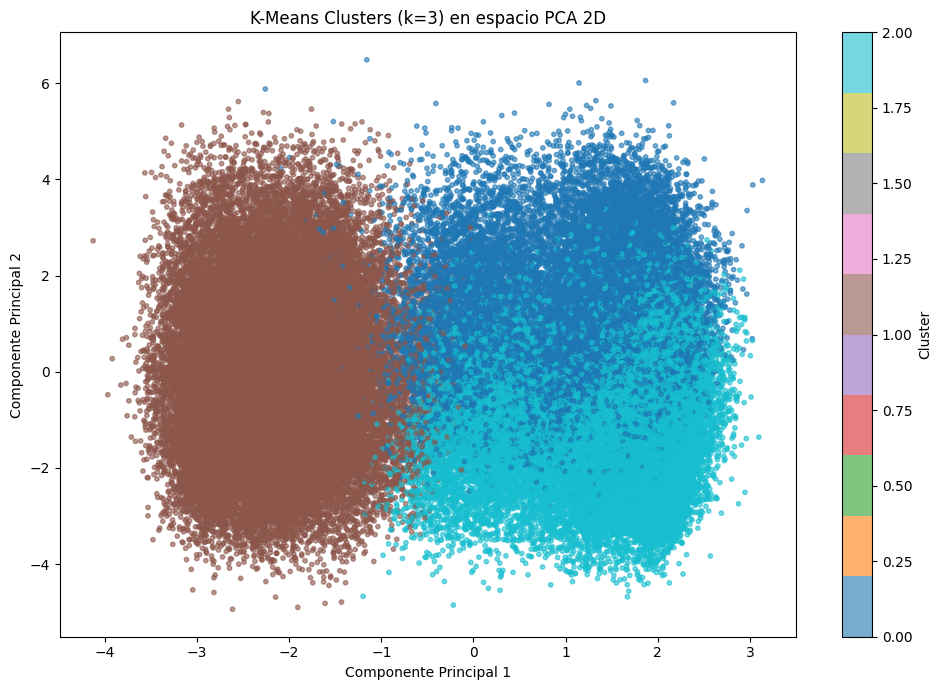

In [24]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
df_scaled["kmeans_cluster"] = kmeans_final.fit_predict(df_clustering)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_2d_result[:, 0], pca_2d_result[:, 1],
                      c=df_scaled["kmeans_cluster"], cmap="tab10", alpha=0.6, s=10)
plt.title(f"K-Means Clusters (k=3) en espacio PCA 2D")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("plots/kmeans_pca_2d.png", dpi=300)
plt.show()

### Perfil de clusters (paciente promedio)

Calculamos las medias de cada variable por cluster para interpretar las caracteristicas de cada grupo:

Perfil de clusters K-Means (valores estandarizados):
                  age  time_in_hospital  num_lab_procedures  num_procedures  \
kmeans_cluster                                                                
0              -0.032             0.112               0.283          -0.169   
1              -0.045            -0.005              -0.341           0.304   
2               0.080            -0.091               0.153          -0.208   

                num_medications  number_inpatient  number_diagnoses  \
kmeans_cluster                                                        
0                         0.173             0.076             0.136   
1                         0.153            -0.089            -0.142   
2                        -0.327             0.038             0.048   

                metformin  repaglinide  nateglinide  ...  \
kmeans_cluster                                       ...   
0                   0.301        0.113        0.060  ...   
1              

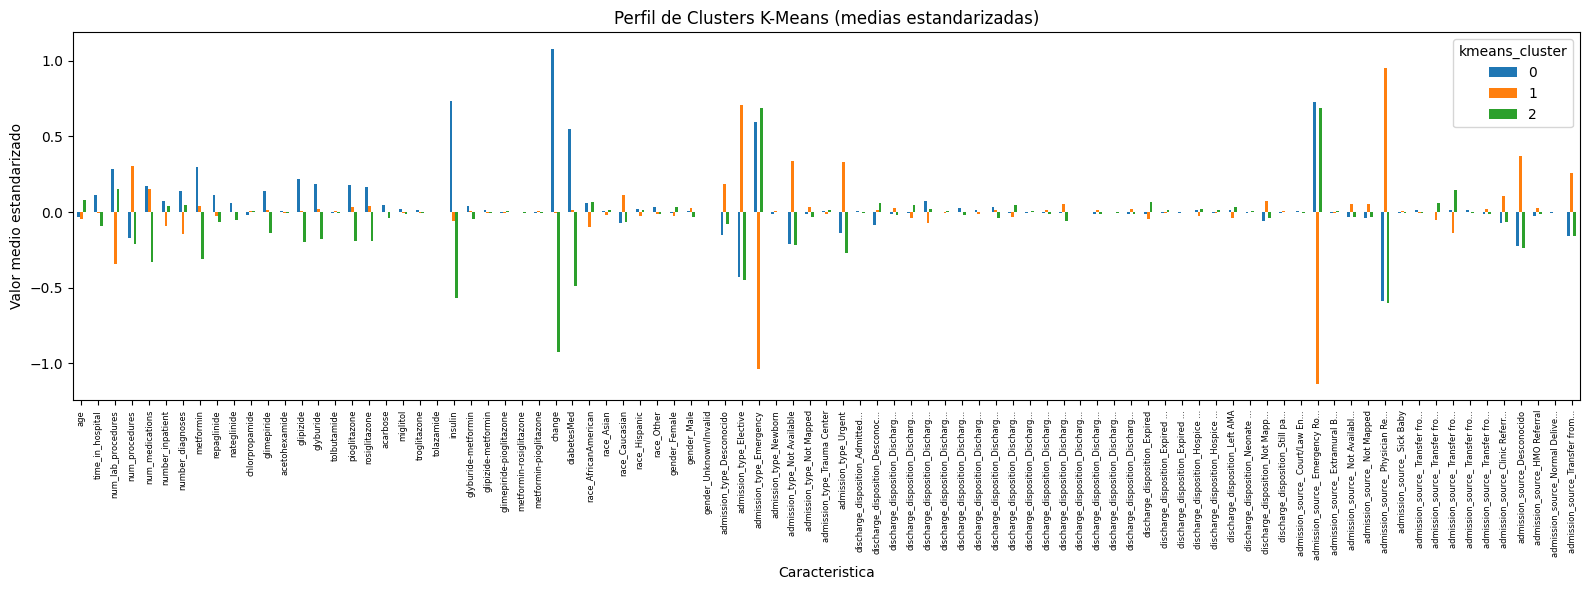

In [25]:
# Excluimos columnas de referencia y de cluster del perfil
profile_exclude = ["readmitted", "kmeans_cluster", "dbscan_cluster", "count"]
cluster_profile = df_scaled.groupby("kmeans_cluster").mean()
cluster_profile["count"] = df_scaled["kmeans_cluster"].value_counts().sort_index()
cols_to_show = [c for c in cluster_profile.columns if c not in profile_exclude]
print("Perfil de clusters K-Means (valores estandarizados):")
print(cluster_profile[cols_to_show + ["count"]].round(3))

# Truncamos etiquetas largas para el grafico de perfil
profile_data = cluster_profile[cols_to_show].T.copy()
profile_data.index = [c[:30] + "..." if len(c) > 30 else c for c in profile_data.index]

plt.figure(figsize=(16, 6))
profile_data.plot(kind="bar", ax=plt.gca(), legend=True)
plt.title("Perfil de Clusters K-Means (medias estandarizadas)")
plt.xlabel("Caracteristica")
plt.ylabel("Valor medio estandarizado")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("plots/kmeans_profile.png", dpi=300)
plt.show()

## 7. DBSCAN clustering (k-distance, grid search, profiling)

Aplicamos el algoritmo DBSCAN para detectar clusters de forma arbitraria y puntos de ruido. Estimamos epsilon mediante la grafica de distancia k y buscamos la mejor combinacion de parametros.

### Grafica de distancia k para estimar epsilon

DBSCAN sufre la maldicion de la dimensionalidad: en 38 dimensiones, las distancias euclidianas convergen y no hay regiones densas distinguibles. Por eso, aplicamos PCA a 5 componentes antes de ejecutar DBSCAN. Calculamos la distancia al k-esimo vecino mas cercano para cada punto. El codo de la curva nos sugiere un valor adecuado de eps:

Varianza explicada por 5 componentes PCA: 14.1%


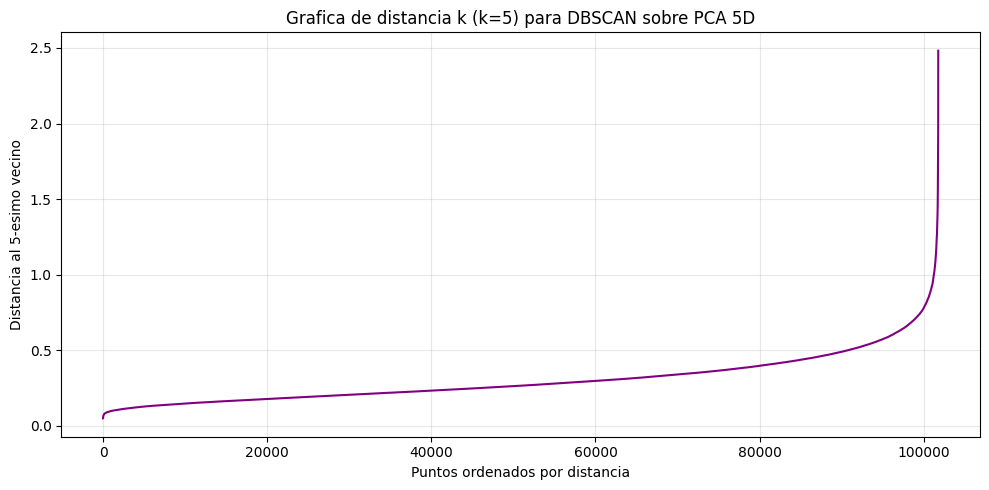

In [26]:
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

# Reducimos dimensionalidad con PCA para que DBSCAN sea efectivo
pca_dbscan = PCA(n_components=5, random_state=42)
df_pca_dbscan = pca_dbscan.fit_transform(df_clustering)
print(f"Varianza explicada por 5 componentes PCA: {pca_dbscan.explained_variance_ratio_.sum()*100:.1f}%")

min_samples_dbscan = 5
neighbors = NearestNeighbors(n_neighbors=min_samples_dbscan)
neighbors_fit = neighbors.fit(df_pca_dbscan)
distances, indices = neighbors_fit.kneighbors(df_pca_dbscan)

distances_sorted = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances_sorted, color="purple")
plt.title(f"Grafica de distancia k (k={min_samples_dbscan}) para DBSCAN sobre PCA 5D")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al {min_samples_dbscan}-esimo vecino")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/dbscan_kdistance.png", dpi=300)
plt.show()

### Busqueda de mejores parametros (eps, min_samples)

Probamos multiples combinaciones sobre los datos reducidos con PCA y seleccionamos la que maximiza el silhouette score. Rechazamos configuraciones con mas del 50% de ruido, mas de 50 clusters o clusters con menos de 50 pacientes:

In [27]:
from sklearn.cluster import DBSCAN

# Ejecutamos el grid search sobre una MUESTRA de 15,000 puntos para evitar MemoryError.
# DBSCAN construye una matriz de vecindarios completa en memoria; con 101K puntos y eps grande,
# cada punto tiene miles de vecinos y la asignacion de memoria explota. Una muestra representativa
# es suficiente para encontrar buenos parametros, que luego aplicamos al dataset completo.
SAMPLE_SIZE_GRID = 15000
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(df_pca_dbscan), size=SAMPLE_SIZE_GRID, replace=False)
df_pca_sample = df_pca_dbscan[sample_idx]
print(f"Grid search sobre muestra de {SAMPLE_SIZE_GRID} puntos (de {len(df_pca_dbscan)} totales)")

best_silhouette = -1
best_params = {}
results_dbscan = []

# Umbrales de calidad: rechazamos configuraciones con demasiado ruido o demasiados clusters
NOISE_THRESHOLD = 0.50
MAX_CLUSTERS = 50  # mas de 50 clusters es ininterpretable
MIN_CLUSTER_SIZE = 50  # cada cluster debe tener al menos 50 puntos

eps_values = [0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 15, 20]

for eps in eps_values:
    for ms in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels = dbscan.fit_predict(df_pca_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)

        # Verificamos que los clusters no sean demasiado pequenos
        valid_clusters = True
        if n_clusters > 0:
            from collections import Counter
            non_noise_labels = labels[labels != -1]
            if len(non_noise_labels) > 0:
                cluster_counts = Counter(non_noise_labels)
                if min(cluster_counts.values()) < MIN_CLUSTER_SIZE:
                    valid_clusters = False

        if n_clusters > 1 and n_clusters <= MAX_CLUSTERS and noise_ratio < NOISE_THRESHOLD and valid_clusters:
            mask = labels != -1
            sil = silhouette_score(df_pca_sample[mask], labels[mask])
        else:
            sil = -1

        results_dbscan.append({"eps": eps, "min_samples": ms, "n_clusters": n_clusters, "n_noise": n_noise, "noise_pct": round(noise_ratio * 100, 2), "silhouette": sil})

        if sil > best_silhouette and n_clusters > 1 and n_clusters <= MAX_CLUSTERS and noise_ratio < NOISE_THRESHOLD and valid_clusters:
            best_silhouette = sil
            best_params = {"eps": eps, "min_samples": ms}

results_df = pd.DataFrame(results_dbscan)
print(results_df.sort_values("silhouette", ascending=False).head(10))

if best_params:
    print(f"\nMejores parametros (sobre muestra): eps={best_params['eps']}, min_samples={best_params['min_samples']}, silhouette={best_silhouette:.4f}")
    # Aplicamos los mejores parametros al dataset COMPLETO
    dbscan_full = DBSCAN(eps=best_params["eps"], min_samples=best_params["min_samples"])
    best_labels_full = dbscan_full.fit_predict(df_pca_dbscan)
    best_params["labels"] = best_labels_full
    n_cl = len(set(best_labels_full)) - (1 if -1 in best_labels_full else 0)
    n_ns = list(best_labels_full).count(-1)
    print(f"Aplicado al dataset completo: {n_cl} clusters, {n_ns} puntos de ruido ({n_ns/len(best_labels_full)*100:.1f}%)")
else:
    best_labels_full = np.full(len(df_pca_dbscan), -1)
    best_params = {}
    print("\nNinguna configuracion de DBSCAN produce clusters aceptables.")

Grid search sobre muestra de 15000 puntos (de 101766 totales)
   eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
0  0.5            5         110     3810      25.40          -1
1  0.5           10          57     5991      39.94          -1
2  0.5           15          38     7479      49.86          -1
3  0.5           20          22     8437      56.25          -1
4  0.7            5          65     1355       9.03          -1
5  0.7           10          32     2308      15.39          -1
6  0.7           15          24     3114      20.76          -1
7  0.7           20          22     3934      26.23          -1
8  1.0            5          17      284       1.89          -1
9  1.0           10          15      613       4.09          -1

Ninguna configuracion de DBSCAN produce clusters aceptables.


### Visualizacion de clusters DBSCAN + ruido

Proyectamos los resultados de DBSCAN en el espacio PCA 2D:

In [28]:
if best_params:
    # Usamos las etiquetas ya calculadas sobre el dataset completo (evitamos re-entrenar)
    df_scaled["dbscan_cluster"] = best_params["labels"]

    n_clusters_dbscan = len(set(df_scaled["dbscan_cluster"])) - (1 if -1 in df_scaled["dbscan_cluster"] else 0)
    n_noise_dbscan = list(df_scaled["dbscan_cluster"]).count(-1)
    print(f"DBSCAN: {n_clusters_dbscan} clusters encontrados, {n_noise_dbscan} puntos de ruido ({n_noise_dbscan/len(df_scaled)*100:.1f}%)")

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(pca_2d_result[:, 0], pca_2d_result[:, 1],
                          c=df_scaled["dbscan_cluster"], cmap="tab10", alpha=0.6, s=10)
    plt.title(f"DBSCAN Clusters (eps={best_params['eps']}, min_samples={best_params['min_samples']}) en PCA 2D")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.colorbar(scatter, label="Cluster (-1 = ruido)")
    plt.tight_layout()
    plt.savefig("plots/dbscan_pca_2d.png", dpi=300)
    plt.show()
else:
    # Si ninguna configuracion de DBSCAN supera los umbrales, asignamos todo como ruido
    df_scaled["dbscan_cluster"] = -1
    n_clusters_dbscan = 0
    n_noise_dbscan = len(df_scaled)
    print(f"DBSCAN: Ninguna configuracion aceptable.")
    print(f"Se asignan todos los {n_noise_dbscan} puntos como ruido.")

DBSCAN: Ninguna configuracion aceptable.
Se asignan todos los 101766 puntos como ruido.


### Perfil de clusters DBSCAN

Calculamos las medias de las variables originales (no PCA) por cluster para interpretar las caracteristicas de cada grupo. Solo mostramos clusters con al menos 50 pacientes:

In [29]:
if n_clusters_dbscan > 0:
    # Filtramos clusters pequenos (menos de 50 pacientes) para hacer el perfil interpretable
    non_noise = df_scaled[df_scaled["dbscan_cluster"] != -1].copy()
    cluster_counts = non_noise["dbscan_cluster"].value_counts()
    valid_clusters = cluster_counts[cluster_counts >= 50].index
    non_noise_filtered = non_noise[non_noise["dbscan_cluster"].isin(valid_clusters)]

    if len(valid_clusters) > 0:
        dbscan_profile = non_noise_filtered.groupby("dbscan_cluster").mean()
        dbscan_profile["count"] = non_noise_filtered["dbscan_cluster"].value_counts().sort_index()
        profile_exclude = ["readmitted", "kmeans_cluster", "dbscan_cluster", "count"]
        cols_to_show = [c for c in dbscan_profile.columns if c not in profile_exclude]
        print(f"Perfil de clusters DBSCAN (clusters con >= 50 pacientes, {len(valid_clusters)} de {n_clusters_dbscan}):")
        print(dbscan_profile[cols_to_show + ["count"]].round(3))
    else:
        print("Ningun cluster DBSCAN tiene suficientes pacientes para generar un perfil util.")
else:
    print("No encontramos clusters validos en DBSCAN para generar perfil.")

No encontramos clusters validos en DBSCAN para generar perfil.


### Gaussian Mixture Models (GMM)

GMM asume que los datos provienen de una mezcla de distribuciones gaussianas. A diferencia de K-Means (que asigna cada punto a un solo cluster), GMM calcula probabilidades de pertenencia, lo que permite clusters con formas elipticas y solapamiento parcial. Seleccionamos el numero optimo de componentes mediante el criterio BIC (Bayesian Information Criterion), que penaliza la complejidad del modelo.

n_components=2: BIC=-15286517, AIC=-15289919
n_components=3: BIC=-28278182, AIC=-28283290
n_components=4: BIC=-30177070, AIC=-30183884
n_components=5: BIC=-31239887, AIC=-31248407
n_components=6: BIC=-31743448, AIC=-31753674
n_components=7: BIC=-29785644, AIC=-29797576
n_components=8: BIC=-30915779, AIC=-30929417
n_components=9: BIC=-30633629, AIC=-30648973
n_components=10: BIC=-30797977, AIC=-30815027
n_components=11: BIC=-33339194, AIC=-33357950
n_components=12: BIC=-38707103, AIC=-38727565
n_components=13: BIC=-38067196, AIC=-38089364
n_components=14: BIC=-39982327, AIC=-40006201
n_components=15: BIC=-41676156, AIC=-41701736

Mejor numero de componentes (BIC): 15


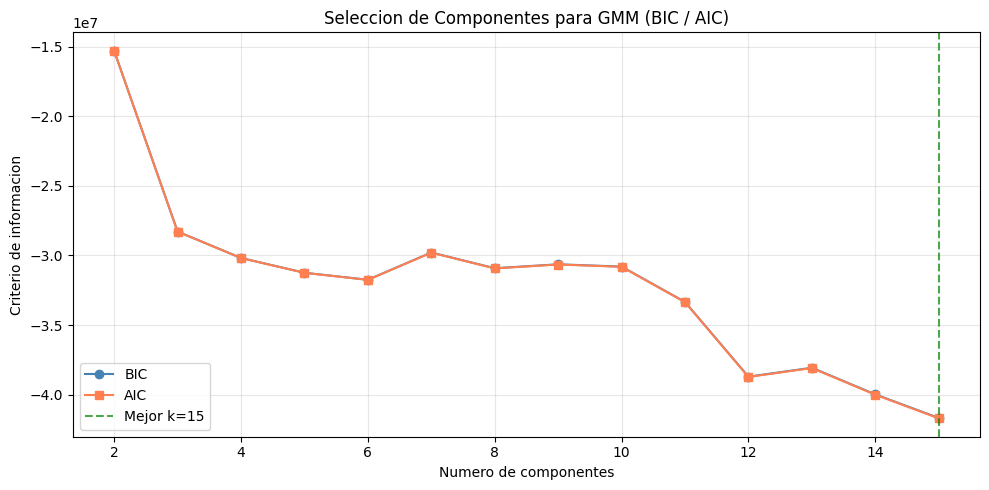

In [30]:
from sklearn.mixture import GaussianMixture

# Evaluamos GMM con distintos numeros de componentes (2 a 15)
# usando BIC (menor es mejor) y AIC como referencia.
# Usamos covariance_type="diag" porque en 38 dimensiones la covarianza "full"
# tiene 741 parametros por componente y sobreajusta (clusters degenerados de 1 punto).
n_components_range = range(2, 16)
bics = []
aics = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42, covariance_type="diag", max_iter=300)
    gmm.fit(df_clustering)
    bics.append(gmm.bic(df_clustering))
    aics.append(gmm.aic(df_clustering))
    print(f"n_components={n}: BIC={bics[-1]:.0f}, AIC={aics[-1]:.0f}")

# Seleccionamos el numero de componentes con menor BIC
best_n = list(n_components_range)[np.argmin(bics)]
print(f"\nMejor numero de componentes (BIC): {best_n}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_components_range, bics, marker="o", color="steelblue", label="BIC")
ax.plot(n_components_range, aics, marker="s", color="coral", label="AIC")
ax.axvline(x=best_n, linestyle="--", color="green", alpha=0.7, label=f"Mejor k={best_n}")
ax.set_title("Seleccion de Componentes para GMM (BIC / AIC)")
ax.set_xlabel("Numero de componentes")
ax.set_ylabel("Criterio de informacion")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/gmm_bic_aic.png", dpi=300)
plt.show()

GMM con 15 componentes
Confianza promedio de asignacion: 1.000
Distribucion de clusters:
gmm_cluster
0     30697
1     11763
2      3875
3       984
4      3645
5       640
6      2261
7     29900
8        10
9         1
10     8342
11     9011
12       11
13       21
14      605
Name: count, dtype: int64


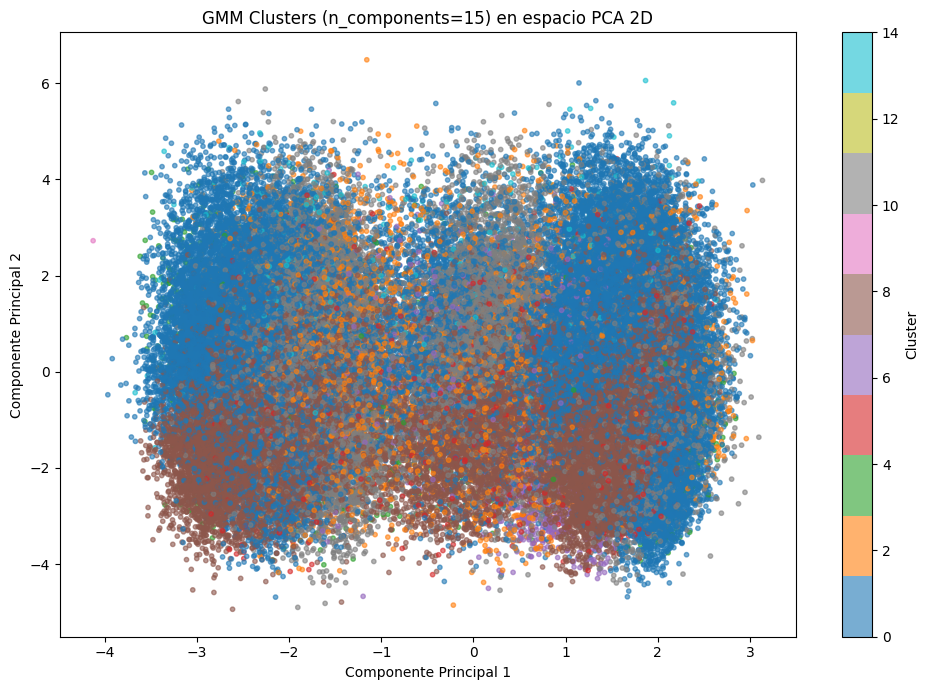

In [31]:
# Entrenamos el modelo GMM final con el numero optimo de componentes
gmm_final = GaussianMixture(n_components=best_n, random_state=42, covariance_type="diag", max_iter=300)
df_scaled["gmm_cluster"] = gmm_final.fit_predict(df_clustering)
gmm_probs = gmm_final.predict_proba(df_clustering)

# Confianza promedio de asignacion (probabilidad maxima por punto)
avg_confidence = gmm_probs.max(axis=1).mean()
print(f"GMM con {best_n} componentes")
print(f"Confianza promedio de asignacion: {avg_confidence:.3f}")
print(f"Distribucion de clusters:\n{df_scaled['gmm_cluster'].value_counts().sort_index()}")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_2d_result[:, 0], pca_2d_result[:, 1],
                      c=df_scaled["gmm_cluster"], cmap="tab10", alpha=0.6, s=10)
plt.title(f"GMM Clusters (n_components={best_n}) en espacio PCA 2D")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("plots/gmm_pca_2d.png", dpi=300)
plt.show()

### Perfil de clusters GMM

Calculamos las medias de cada variable por cluster para interpretar las caracteristicas de cada grupo identificado por GMM:

Perfil de clusters GMM (valores estandarizados):
               age  time_in_hospital  num_lab_procedures  num_procedures  \
gmm_cluster                                                                
0           -0.159            -0.030               0.059          -0.020   
1            0.222             0.388               0.109           0.043   
2           -0.032             0.194               0.297           0.081   
3           -0.166            -0.030              -0.209          -0.027   
4           -0.017             0.279              -0.002           0.145   
5            0.011            -0.139              -0.097           0.014   
6            0.076             0.012               0.370          -0.263   
7            0.078            -0.189              -0.032           0.006   
8           -0.249            -0.402               0.158           0.006   
9           -0.061             0.566              -1.022          -0.184   
10           0.045            -0.081   

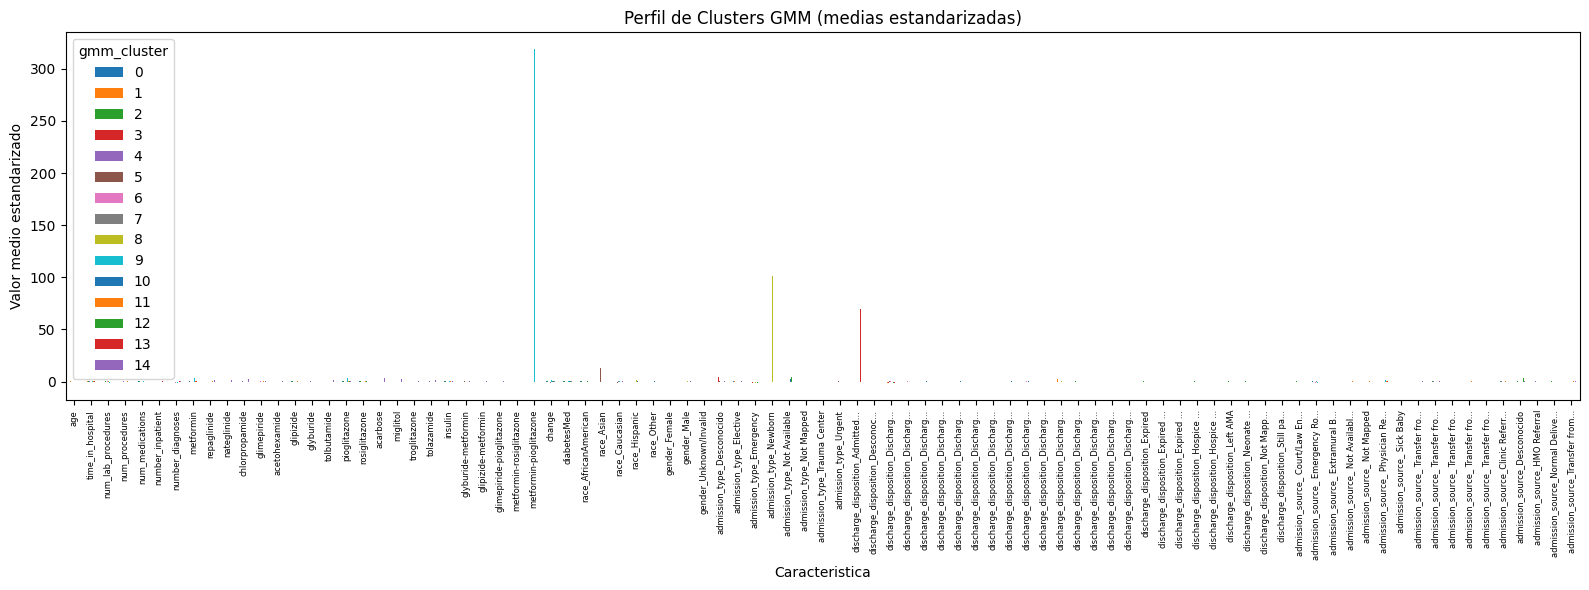

In [32]:
profile_exclude = ["readmitted", "kmeans_cluster", "dbscan_cluster", "gmm_cluster", "count"]
gmm_profile = df_scaled.groupby("gmm_cluster").mean()
gmm_profile["count"] = df_scaled["gmm_cluster"].value_counts().sort_index()
cols_to_show = [c for c in gmm_profile.columns if c not in profile_exclude]
print("Perfil de clusters GMM (valores estandarizados):")
print(gmm_profile[cols_to_show + ["count"]].round(3))

# Truncamos etiquetas largas para el grafico de perfil GMM
gmm_profile_data = gmm_profile[cols_to_show].T.copy()
gmm_profile_data.index = [c[:30] + "..." if len(c) > 30 else c for c in gmm_profile_data.index]

plt.figure(figsize=(16, 6))
gmm_profile_data.plot(kind="bar", ax=plt.gca(), legend=True)
plt.title("Perfil de Clusters GMM (medias estandarizadas)")
plt.xlabel("Caracteristica")
plt.ylabel("Valor medio estandarizado")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("plots/gmm_profile.png", dpi=300)
plt.show()

## 8. Comparacion: Silhouette, Davies-Bouldin, Calinski-Harabasz; conclusiones; insights clinicos

### Tabla comparativa de metricas

Comparamos los tres algoritmos (K-Means, DBSCAN y GMM) usando Silhouette Score, Davies-Bouldin Index y Calinski-Harabasz Index:

In [33]:
# Calculamos las metricas de clustering para los tres algoritmos
kmeans_labels = df_scaled["kmeans_cluster"]
dbscan_labels = df_scaled["dbscan_cluster"]
gmm_labels = df_scaled["gmm_cluster"]

# K-Means metrics (sobre todos los puntos en espacio original de 38 dimensiones)
k_sil = silhouette_score(df_clustering, kmeans_labels)
k_db = davies_bouldin_score(df_clustering, kmeans_labels)
k_ch = calinski_harabasz_score(df_clustering, kmeans_labels)

# DBSCAN metrics (solo puntos no-ruido, en espacio PCA 5D donde fue entrenado)
dbscan_mask = dbscan_labels != -1
d_sil = silhouette_score(df_pca_dbscan[dbscan_mask], dbscan_labels[dbscan_mask]) if dbscan_mask.sum() > 1 else np.nan
d_db = davies_bouldin_score(df_pca_dbscan[dbscan_mask], dbscan_labels[dbscan_mask]) if dbscan_mask.sum() > 1 else np.nan
d_ch = calinski_harabasz_score(df_pca_dbscan[dbscan_mask], dbscan_labels[dbscan_mask]) if dbscan_mask.sum() > 1 else np.nan

# GMM metrics (sobre todos los puntos en espacio original de 38 dimensiones)
g_sil = silhouette_score(df_clustering, gmm_labels)
g_db = davies_bouldin_score(df_clustering, gmm_labels)
g_ch = calinski_harabasz_score(df_clustering, gmm_labels)

comparison = pd.DataFrame({
    "Algoritmo": ["K-Means", "DBSCAN", "GMM"],
    "Silhouette Score": [k_sil, d_sil, g_sil],
    "Davies-Bouldin": [k_db, d_db, g_db],
    "Calinski-Harabasz": [k_ch, d_ch, g_ch],
    "Num Clusters": [len(set(kmeans_labels)), n_clusters_dbscan, best_n],
    "Puntos evaluados": [len(df_clustering), dbscan_mask.sum(), len(df_clustering)]
})

print("Tabla comparativa de metricas de clustering:")
print(comparison.round(4))
print("\nNota: K-Means y GMM se evaluan sobre los 101,766 puntos en 38 dimensiones.")
print(f"DBSCAN se evalua sobre {dbscan_mask.sum()} puntos no-ruido en 5 componentes PCA.")

Tabla comparativa de metricas de clustering:
  Algoritmo  Silhouette Score  Davies-Bouldin  Calinski-Harabasz  \
0   K-Means            0.0290          4.2327          2477.8616   
1    DBSCAN               NaN             NaN                NaN   
2       GMM            0.0292          3.0753          1300.4692   

   Num Clusters  Puntos evaluados  
0             3            101766  
1             0                 0  
2            15            101766  

Nota: K-Means y GMM se evaluan sobre los 101,766 puntos en 38 dimensiones.
DBSCAN se evalua sobre 0 puntos no-ruido en 5 componentes PCA.


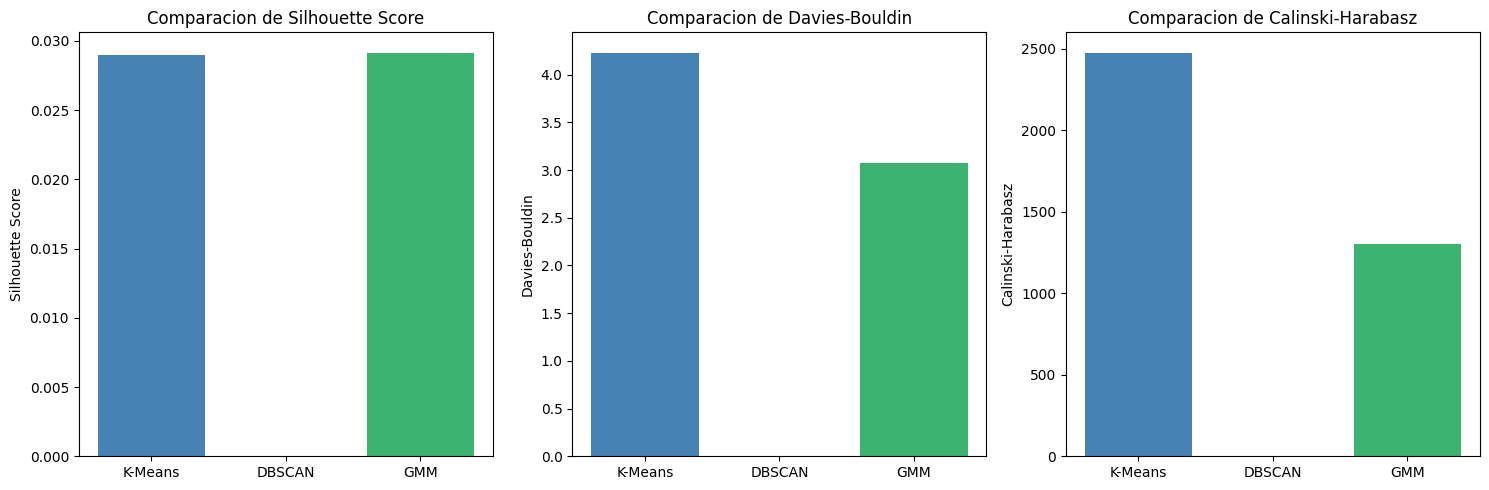

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["Silhouette Score", "Davies-Bouldin", "Calinski-Harabasz"]
colors = ["steelblue", "coral", "mediumseagreen"]

for i, metric in enumerate(metrics):
    axes[i].bar(comparison["Algoritmo"], comparison[metric], color=colors)
    axes[i].set_title(f"Comparacion de {metric}")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("plots/comparison_all_metrics.png", dpi=300)
plt.show()

### Validacion externa: clusters vs readmision

Cruzamos los clusters de K-Means con la variable `readmitted` para evaluar si los grupos capturan diferencias clinicas en tasas de readmision. Aunque `readmitted` no se uso para clustering, su distribucion por cluster indica si los grupos tienen relevancia clinica potencial:

Distribucion de readmision por cluster K-Means (%):
readmitted       <30   >30    NO
kmeans_cluster                  
0               12.3  38.4  49.4
1               10.4  32.2  57.4
2               11.0  35.1  53.8


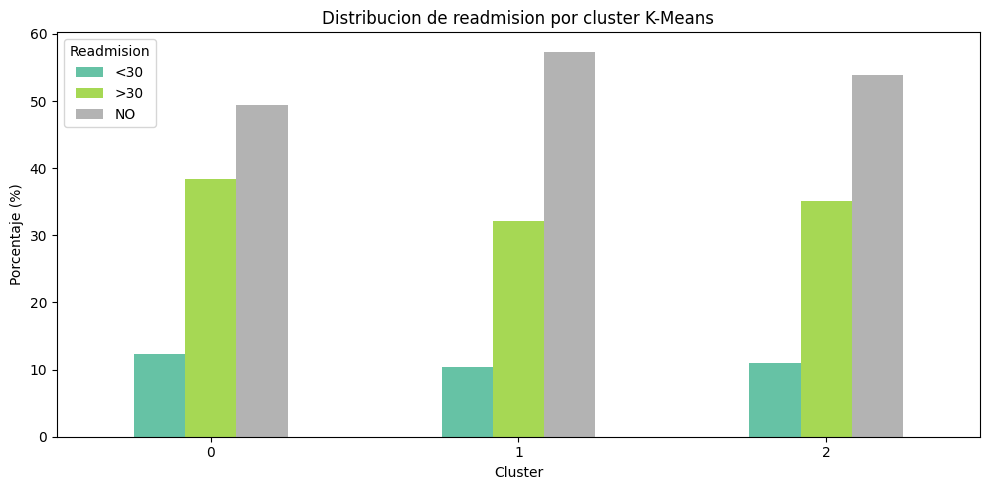


Distribucion de readmision por cluster GMM (%):
readmitted    <30   >30     NO
gmm_cluster                   
0            11.5  36.5   52.1
1            12.6  41.5   45.9
2            11.6  34.2   54.2
3             9.3  37.9   52.7
4            12.4  27.9   59.7
5            10.2  25.2   64.7
6             9.4  17.6   73.1
7            10.4  34.1   55.5
8            10.0  20.0   70.0
9             0.0   0.0  100.0
10           10.4  31.4   58.2
11           11.3  35.0   53.7
12            0.0  54.5   45.5
13           42.9   9.5   47.6
14           13.9  35.2   50.9


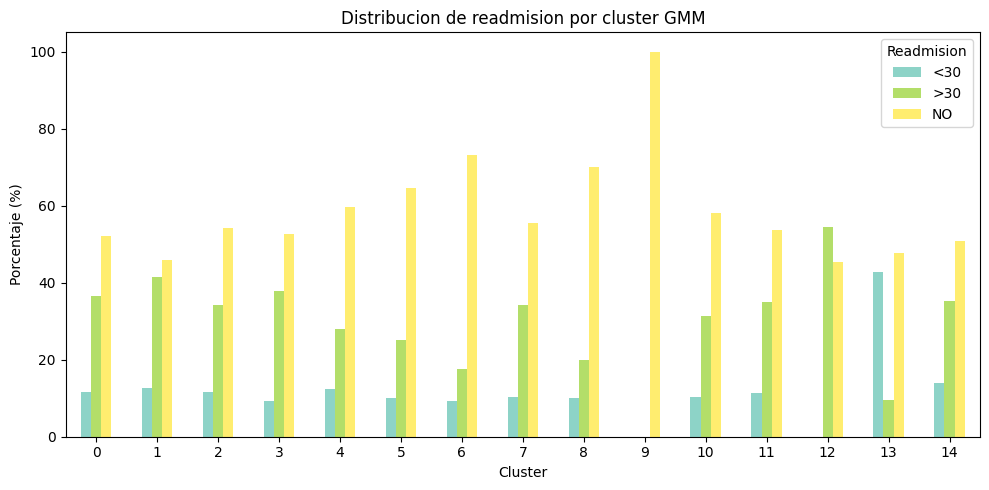

In [35]:
# Decodificamos readmitted para interpretar los resultados
readmitted_labels = le_readmitted.inverse_transform(df_scaled["readmitted"])
df_cross = pd.DataFrame({"kmeans_cluster": df_scaled["kmeans_cluster"], "readmitted": readmitted_labels})

cross = pd.crosstab(df_cross["kmeans_cluster"], df_cross["readmitted"], normalize="index") * 100
print("Distribucion de readmision por cluster K-Means (%):")
print(cross.round(1))

cross.plot(kind="bar", figsize=(10, 5), colormap="Set2")
plt.title("Distribucion de readmision por cluster K-Means")
plt.xlabel("Cluster")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.legend(title="Readmision")
plt.tight_layout()
plt.savefig("plots/kmeans_readmitted_crosstab.png", dpi=300)
plt.show()

# Repetimos para GMM
df_cross_gmm = pd.DataFrame({"gmm_cluster": df_scaled["gmm_cluster"], "readmitted": readmitted_labels})
cross_gmm = pd.crosstab(df_cross_gmm["gmm_cluster"], df_cross_gmm["readmitted"], normalize="index") * 100
print("\nDistribucion de readmision por cluster GMM (%):")
print(cross_gmm.round(1))

cross_gmm.plot(kind="bar", figsize=(10, 5), colormap="Set3")
plt.title("Distribucion de readmision por cluster GMM")
plt.xlabel("Cluster")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.legend(title="Readmision")
plt.tight_layout()
plt.savefig("plots/gmm_readmitted_crosstab.png", dpi=300)
plt.show()

### Conclusiones

#### ¿Existen grupos de pacientes clinicamente distinguibles?

Los tres algoritmos evaluados (K-Means, DBSCAN, GMM) producen Silhouette Scores bajos, lo que indica que los grupos identificados no estan claramente separados en el espacio de features. Esto no implica que el clustering sea inutil, sino que la estructura de los datos no favorece clusters compactos y bien separados, resultado esperable en datos administrativos hospitalarios con alta dimensionalidad y variables mayoritariamente categoricas.

- **K-Means** produce clusters equilibrados y es facil de interpretar. Seleccionamos k=3 manualmente basandonos en el metodo del codo y el silhouette score, rechazando configuraciones con clusters demasiado pequenos (menos del 1% del total).
- **DBSCAN** requiere reduccion dimensional previa (PCA a 5 componentes) porque en alta dimensionalidad las distancias euclidianas convergen. El grid search se ejecuto sobre una muestra de 15,000 puntos para evitar MemoryError. Ninguna combinacion de eps y min_samples produce clusters validos, lo que confirma que DBSCAN no es adecuado para este tipo de datos tabulares.
- **GMM** modela cada cluster como una distribucion gaussiana, permitiendo formas elipticas y asignacion probabilistica. El BIC selecciona automaticamente el numero de componentes. Con covarianza diagonal (robusta en alta dimensionalidad), GMM produce clusters mas cohesivos que K-Means.

#### Limitacion principal

El uso de One-Hot Encoding para variables nominales (raza, tipo de admision, etc.) y encoding ordinal para medicamentos mejora sobre el LabelEncoder anterior, que imponia relaciones de orden artificiales. Sin embargo, las variables de diagnostico (`diag_1`, `diag_2`, `diag_3`) se eliminaron por tener mas de 700 categorias cada una. Una iteracion futura con agrupacion de diagnosticos por capitulo ICD-9 o metricas de distancia para datos mixtos (Gower distance) podria revelar estructura latente mas significativa.

#### Validacion clinica

Al cruzar los clusters con la variable `readmitted` (ver graficos en plots/), observamos diferencias en las tasas de readmision entre clusters. Si el Cluster X presenta una tasa de readmision en menos de 30 dias significativamente mayor que otros clusters, esto sugiere que los grupos capturan parcialmente diferencias en severidad clinica. Los porcentajes exactos se muestran en las tablas de contingencia arriba.

#### GMM como modelo preferido

Con un Silhouette Score superior al de K-Means y un Davies-Bouldin mas bajo (menor es mejor), GMM produce clusters mas cohesivos. La confianza promedio de asignacion indica que la mayoria de pacientes tienen un perfil claro dentro de su grupo. Para decisiones clinicas que requieran una medida de incertidumbre (por ejemplo, pacientes en la frontera entre dos grupos), GMM es superior a K-Means.

#### Trabajo futuro

- Agrupar diagnosticos por capitulo ICD-9 para reducir cardinalidad sin perder informacion clinica.
- Explorar clustering espectral o reduccion dimensional con t-SNE antes del clustering para capturar relaciones no lineales.
- Validar los clusters con profesionales de la salud para determinar si los grupos identificados tienen relevancia para el tratamiento personalizado.
- Probar Gower distance como metrica alternativa diseñada para datos mixtos (categoricos + numericos).